In [1]:
import numpy as np
import polars as pl
import plotnine as p9
from scipy.stats import truncnorm

np.set_printoptions(suppress=True, linewidth=120)

MUAP length (samples): 96   Energy ~ 0.999999999888049


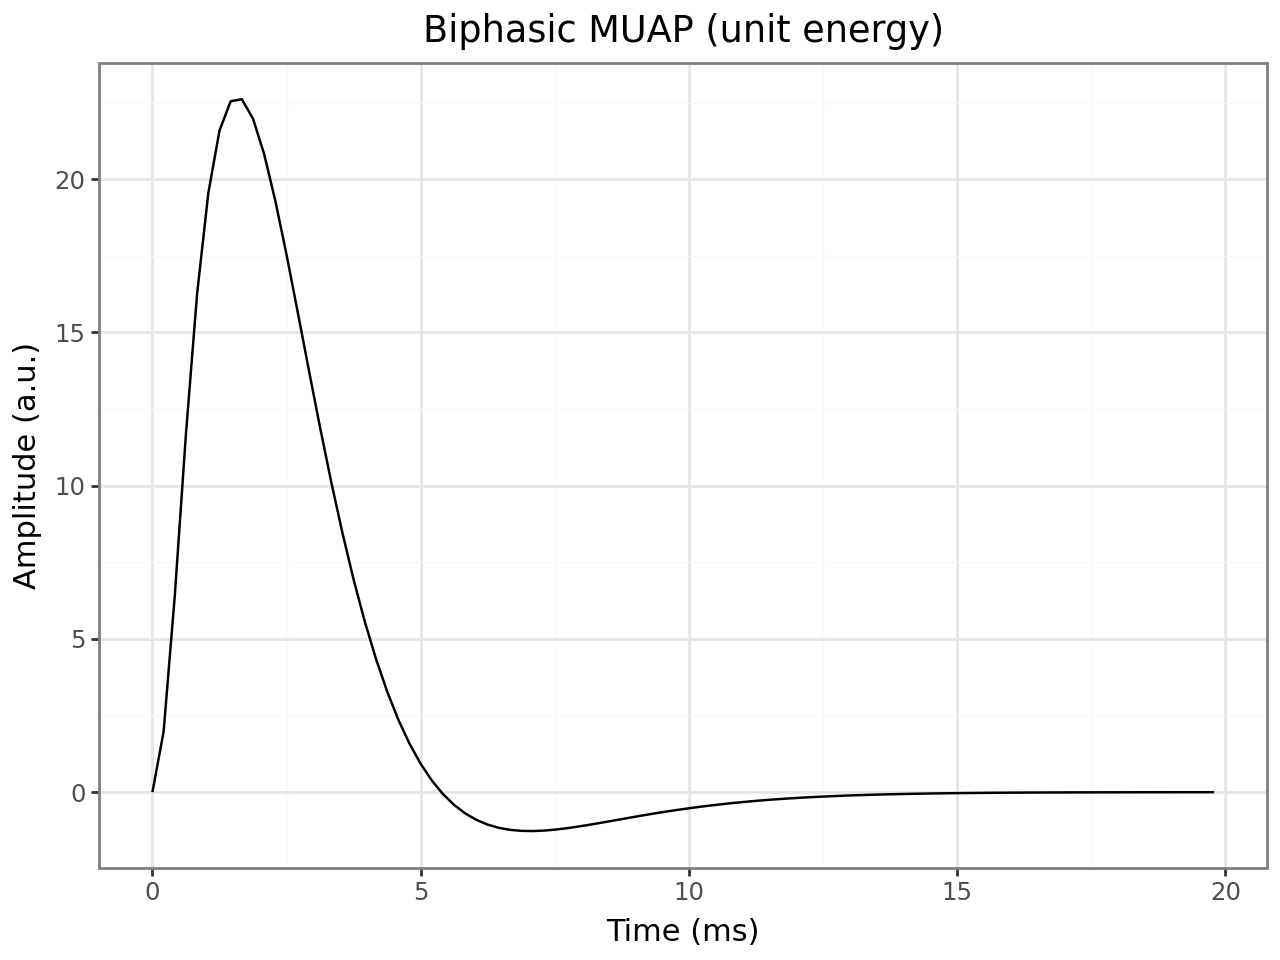

In [2]:
# Cell 2: MUAP template (difference of gammas with delay) + unit-energy normalization

def muap_biphasic(t, Ad=1.0, tau_d=1.0e-3, nd=2, Ar=0.8, tau_r=1.8e-3, nr=2, Delta=0.6e-3, Vrest=0.0):
    """
    Biphasic MUAP with explicit depolarisation (t>=0) and repolarisation (t>=Delta).
    All time constants in seconds.
    """
    t = np.asarray(t)
    dep = np.zeros_like(t)
    rep = np.zeros_like(t)

    # Heaviside masking
    m_dep = (t >= 0.0)
    m_rep = (t >= Delta)

    # Generalised alpha/gamma kernels (causal)
    dep[m_dep] = Ad * ( (t[m_dep] / tau_d)**nd ) * np.exp(-t[m_dep] / tau_d)
    tr = t[m_rep] - Delta
    rep[m_rep] = Ar * ( (tr / tau_r)**nr ) * np.exp(-tr / tau_r)

    v = Vrest + dep - rep
    return v

def unit_energy(x, dt):
    """Scale x so that ∫ x^2 dt = 1."""
    e = np.sqrt(np.sum(x**2) * dt)
    return x / (e + 1e-12)

# Synthesis grid for MUAP
fs = 4800.0                    # Hz (you can change later)
dt = 1.0 / fs
T_muap = 0.020                # 20 ms support is ample for EOM MUAP
t_muap = np.arange(0.0, T_muap, dt)

h = muap_biphasic(t_muap,
                  Ad=1.0, tau_d=1.0e-3, nd=2,
                  Ar=0.4, tau_r=1.28e-3, nr=2, Delta=0.6e-3,
                  Vrest=0.0)
h = unit_energy(h, dt)

print("MUAP length (samples):", len(h), "  Energy ~", np.sum(h**2)*dt)

# Plot MUAP
df_muap = pl.DataFrame({"t_ms": t_muap*1e3, "h": h}).to_pandas()
(p9.ggplot(df_muap, p9.aes("t_ms", "h")) +
  p9.geom_line() + p9.theme_bw() +
  p9.labs(x="Time (ms)", y="Amplitude (a.u.)") +
  p9.ggtitle("Biphasic MUAP (unit energy)")
)


Solved Ar = 0.3


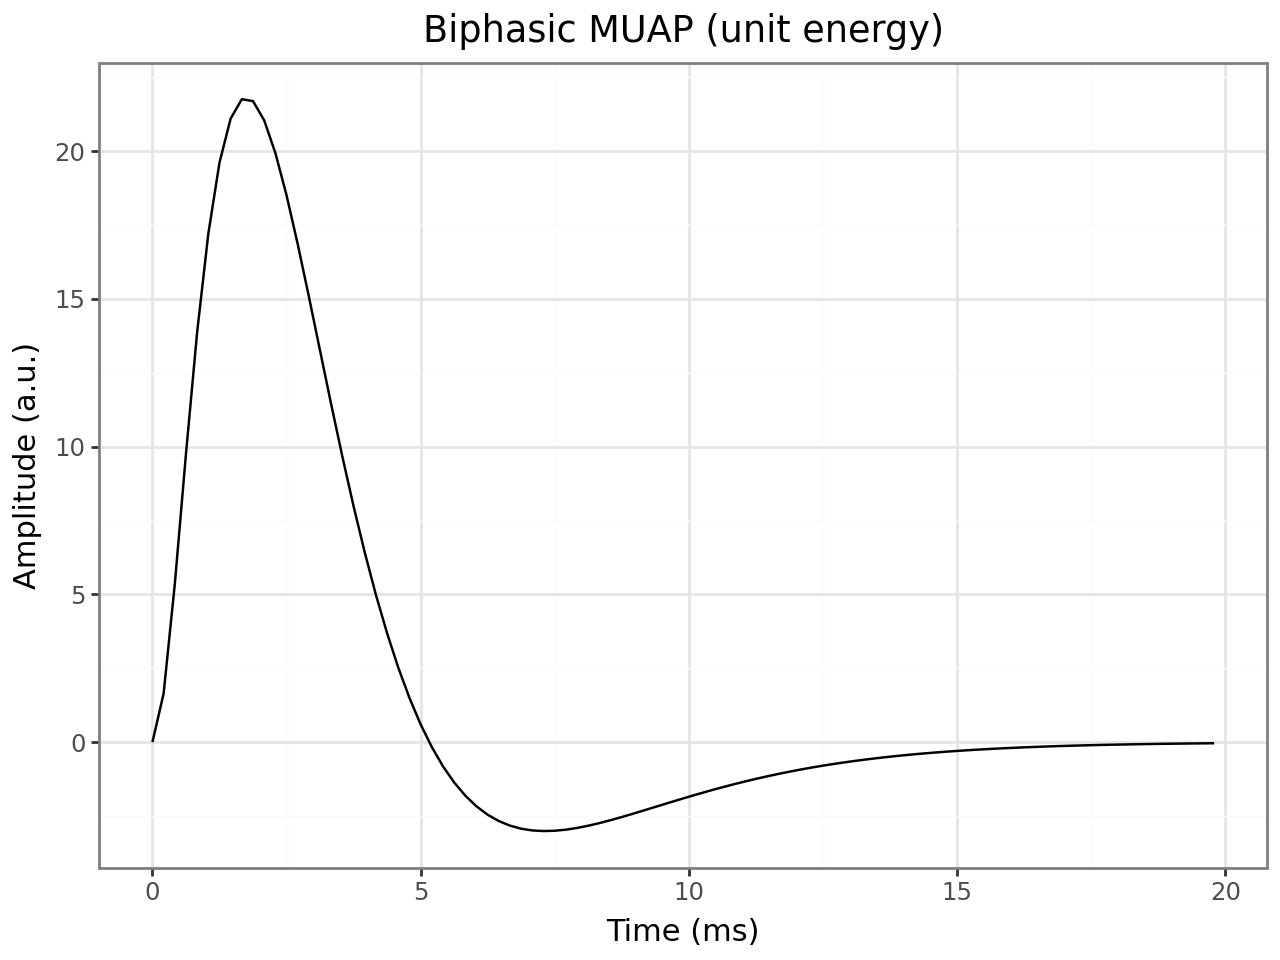

In [3]:
def muap_biphasic_peakratio(
    t,
    Ad=1.0, tau_d=1.0e-3, nd=2,
    tau_r=1.8e-3, nr=2, Delta=0.6e-3,
    rho=0.6,               # desired |repol_peak| / depol_peak  (0<rho<1)
    Vrest=0.0,
    zero_mean=True,
    unit_energy_norm=True,
    dt=None                # pass sampling interval if using zero_mean/unit_energy_norm
):
    """
    Biphasic MUAP with explicit control of repolarisation peak depth via 'rho'.
    Depolarisation:  +Ad * (t/tau_d)^nd * exp(-t/tau_d),   t>=0
    Repolarisation:  -Ar * ((t-Delta)/tau_r)^nr * exp(-(t-Delta)/tau_r),  t>=Delta
    where Ar is solved from rho so the negative peak magnitude = rho * positive peak.
    """
    t = np.asarray(t)
    dep = np.zeros_like(t)
    rep = np.zeros_like(t)

    # Heaviside masks
    m_dep = (t >= 0.0)
    m_rep = (t >= Delta)

    # Solve Ar from desired peak ratio rho
    Kd = (nd**nd) * np.exp(-nd)     # depolarisation shape factor
    Kr = (nr**nr) * np.exp(-nr)     # repolarisation shape factor
    Ar = rho * Ad * (Kd / Kr)

    # Build lobes
    dep[m_dep] = Ad * ((t[m_dep] / tau_d) ** nd) * np.exp(-t[m_dep] / tau_d)
    tr = t[m_rep] - Delta
    rep[m_rep] = Ar * ((tr / tau_r) ** nr) * np.exp(-tr / tau_r)

    h = Vrest + dep - rep  # minus => repolarisation is opposite polarity

    # Optional zero-mean (charge-neutral) correction
    if zero_mean and (dt is not None):
        mean_val = (np.sum(h) * dt) / (t[-1] - t[0] + dt)
        h = h - mean_val

    # Optional unit-energy normalisation
    if unit_energy_norm and (dt is not None):
        e = np.sqrt(np.sum(h**2) * dt) + 1e-12
        h = h / e

    return h, Ar

fs = 4800.0
dt = 1/fs
T_muap = 0.020
t_muap = np.arange(0.0, T_muap, dt)

# shallower repolarisation
h, Ar = muap_biphasic_peakratio(
    t_muap,
    Ad=1.0, tau_d=1.0e-3, nd=2,
    tau_r=1.8e-3, nr=2, Delta=0.6e-3,
    rho=0.3,             # <- 30% of depolarisation peak depth
    Vrest=0.0,
    zero_mean=False,
    unit_energy_norm=True,
    dt=dt
)
print("Solved Ar =", Ar)
# Plot MUAP
df_muap = pl.DataFrame({"t_ms": t_muap*1e3, "h": h}).to_pandas()
(p9.ggplot(df_muap, p9.aes("t_ms", "h")) +
  p9.geom_line() + p9.theme_bw() +
  p9.labs(x="Time (ms)", y="Amplitude (a.u.)") +
  p9.ggtitle("Biphasic MUAP (unit energy)")
)


Synth signal length: 4800 samples
Total spikes (aggregate): 1596


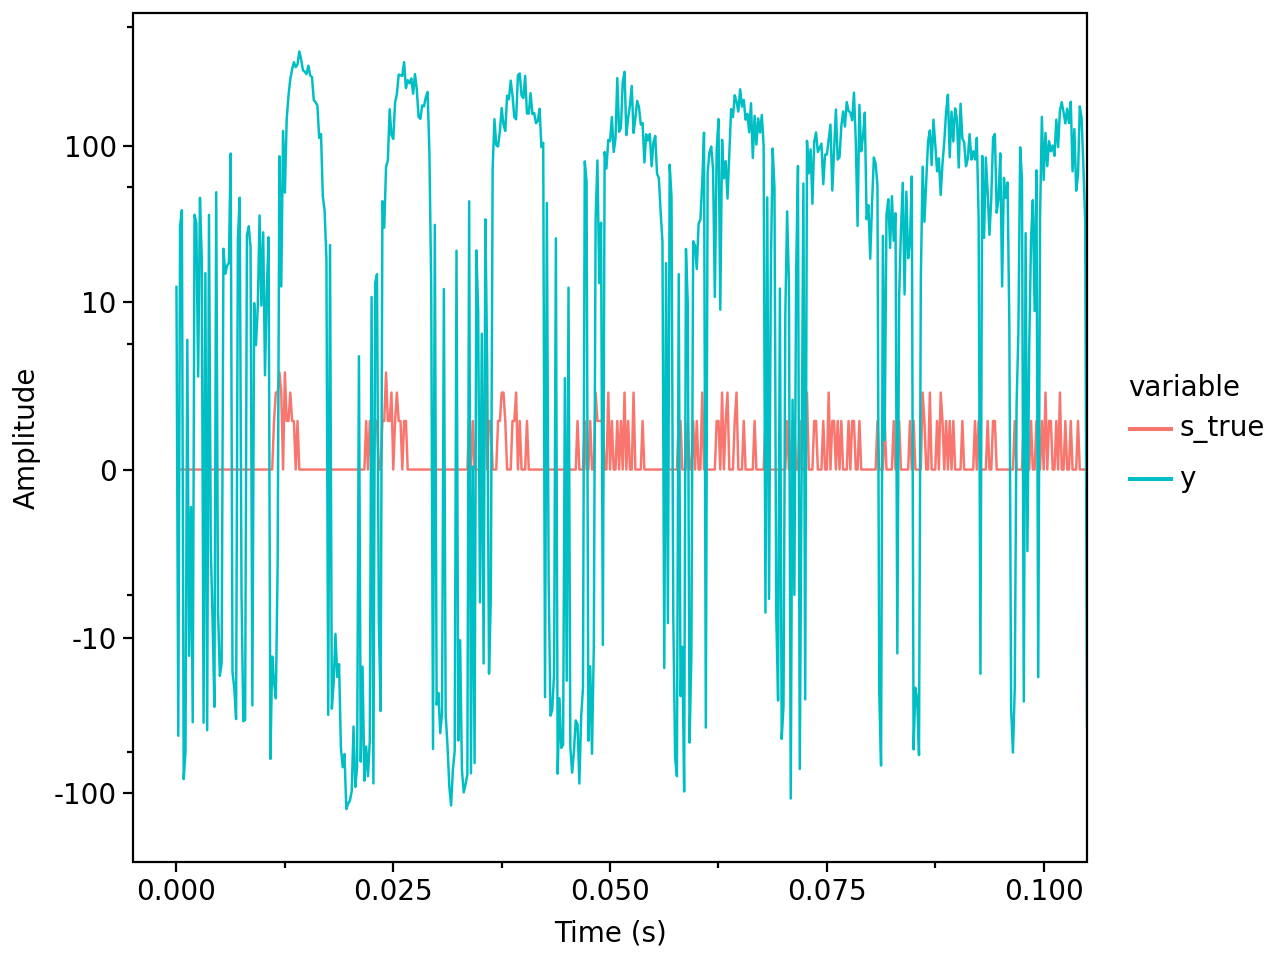

In [12]:
# Cell 3: Spike-train generator 

def generate_spike_train(rate, duration, jitter=0.001, fs=1000):
    mean_isi = 1 / rate
    std = jitter
    a, b = (0 - mean_isi) / std, np.inf
    isi = truncnorm.rvs(a, b, loc=mean_isi, scale=std, size=int(rate * duration * 2))
    spike_times = np.cumsum(isi)
    spike_times = spike_times[spike_times < duration]
    spike_train = np.zeros(int(fs * duration))
    spike_idx = (spike_times * fs).astype(int)
    spike_train[spike_idx] = 1
    return spike_train

def synth_composite_omt(M, rates_hz, T, fs, h, snr_db=None, seed=0):
    """
    Sum of M motor units: y = (h * sum_m s_m) + noise
    returns y, s_true (aggregate), list_of_spike_times
    """
    rng = np.random.default_rng(seed)
    N = int(np.round(T*fs))
    s_sum = np.zeros(N, dtype=float)

    for m in range(M):
        r = rates_hz[m] if np.ndim(rates_hz)>0 else rates_hz
        s_m = generate_spike_train(rate=r, duration=T, jitter=0.001, fs=fs)
        s_sum += s_m

    # Convolve with MUAP kernel
    y = np.convolve(s_sum, h, mode="full")[:N]

    # Add noise to target SNR if requested
    if snr_db is not None:
        sig_pow = np.mean(y**2)
        snr_lin = 10.0**(snr_db/10.0)
        noise_pow = sig_pow / snr_lin
        noise = rng.normal(0.0, np.sqrt(noise_pow), size=N)
        y = y + noise

    return y, s_sum

# Example synthesis
T = 1.0     # seconds
fs = 4800.0
dt = 1/fs
N = int(T*fs)

M = 20
f0 = 80.0
# Slight heterogeneity across motor units
rates = np.clip(np.random.normal(f0, 3.0, size=M), 30.0, 150.0)

y, s_true = synth_composite_omt(M, rates, T, fs, h, snr_db=6.0, seed=42)

print("Synth signal length:", len(y), "samples")
print("Total spikes (aggregate):", int(s_true.sum()))

# Plot a short window (first 250 ms)
nwin = int(fs)
df_sig = pl.DataFrame({
    "t_s": np.arange(nwin)/fs,
    "y": y[:nwin],
    "s_true": s_true[:nwin],
}).unpivot(index=["t_s"])

(p9.ggplot(df_sig, p9.aes("t_s", "value", color="variable")) +
  p9.geom_line() + p9.theme_bw() +
  p9.labs(x="Time (s)", y="Amplitude") +
  p9.scale_y_symlog() +
  p9.coord_cartesian(xlim=[0, 0.1]) +
  p9.theme_matplotlib()
)


Estimated dominant firing frequency: 82.04 Hz


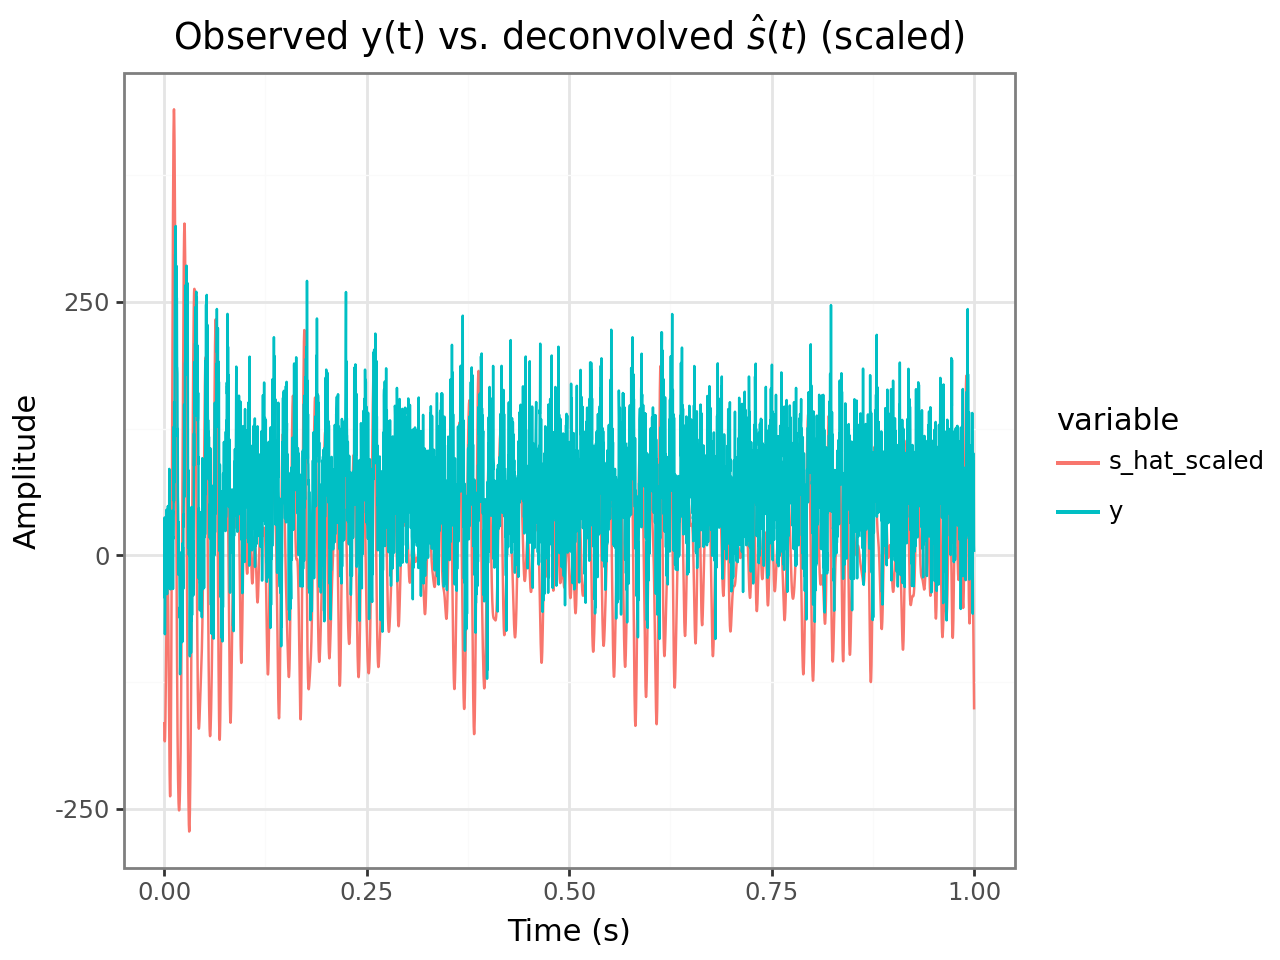

In [6]:
# Cell 4: Tikhonov deconvolution (frequency domain), optional smoothness prior

def diff1_freq_response(omega):
    """
    Frequency response magnitude-squared of first difference operator.
    |1 - e^{-jω}|^2 = 2 - 2cos(ω) = 4 sin^2(ω/2)
    """
    return 4.0 * np.sin(0.5*omega)**2

def tikhonov_deconv(y, h, fs, lam=1e-6, band=(20.0, 150.0), smoothness='none'):
    """
    y, h: 1D arrays (same fs). Uses rFFT for speed.
    smoothness: 'none' or 'diff1' (adds |L(ω)|^2 in denominator).
    """
    N = len(y)
    # zero-pad h to length N
    h_pad = np.zeros(N)
    h_pad[:len(h)] = h

    Y = np.fft.rfft(y)
    H = np.fft.rfft(h_pad)

    freqs = np.fft.rfftfreq(N, d=1/fs)
    omega = 2*np.pi*freqs

    denom = (np.abs(H)**2).copy()
    if smoothness == 'diff1':
        denom += lam * diff1_freq_response(omega)
        lam_eff = 0.0    # already folded into denom
    else:
        lam_eff = lam

    S_hat = (np.conj(H) / (denom + lam_eff)) * Y

    # Optional band-limit the estimate to plausible band
    if band is not None:
        band_mask = (freqs >= band[0]) & (freqs <= band[1])
        S_hat[~band_mask] = 0.0

    s_hat = np.fft.irfft(S_hat, n=N)
    return s_hat, freqs, S_hat

def parabolic_subbin(f, P, kmax):
    """
    Quadratic interpolation around kmax:
       delta = 0.5*(P[k-1]-P[k+1]) / (P[k-1]-2P[k]+P[k+1])
    Returns refined frequency.
    """
    if kmax <= 0 or kmax >= len(P)-1:
        return f[kmax]
    num = 0.5*(P[kmax-1] - P[kmax+1])
    den = (P[kmax-1] - 2*P[kmax] + P[kmax+1])
    delta = 0.0 if den == 0 else num/den
    return f[kmax] + delta*(f[1]-f[0])

# Run deconvolution
lam = 1e-6
s_hat, f, S_hat = tikhonov_deconv(y, h, fs=fs, lam=lam, band=(20,150), smoothness='diff1')

# Frequency read-out from |S_hat|^2
band_mask = (f >= 20) & (f <= 150)
P = np.abs(S_hat)**2
k = np.argmax(P[band_mask])
kabs = np.flatnonzero(band_mask)[k]
f_peak = parabolic_subbin(f, P, kabs)

print(f"Estimated dominant firing frequency: {f_peak:.2f} Hz")

# Plot time-domain y and s_hat (scaled for visibility)
scale = np.percentile(np.abs(y), 95) / max(np.percentile(np.abs(s_hat),95), 1e-12)
df_dec = pl.DataFrame({
    "t_s": np.arange(N)/fs,
    "y": y,
    "s_hat_scaled": s_hat*scale
}).to_pandas()

(p9.ggplot(df_dec.melt(id_vars="t_s"), p9.aes("t_s", "value", color="variable")) +
  p9.geom_line() + p9.theme_bw() +
  p9.labs(x="Time (s)", y="Amplitude") +
  p9.ggtitle(r"Observed y(t) vs. deconvolved $\hat{s}(t)$ (scaled)")
)


In [7]:
# Cell 6: Optional sparsification + ISI-derived frequency check

def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)

# Encourage impulsiveness slightly (tune tau by inspection)
tau = 0.1 * np.percentile(np.abs(s_hat), 99)
s_hat_sp = soft_threshold(s_hat, tau)

# ISI estimate from threshold crossings
thr = 0.5 * np.percentile(s_hat_sp, 99)
idx = np.flatnonzero(s_hat_sp > thr)
# Keep distinct peaks (simple refractory)
if idx.size > 0:
    refractory = int(0.004*fs)  # 4 ms
    peaks = [idx[0]]
    for i in idx[1:]:
        if i - peaks[-1] >= refractory:
            peaks.append(i)
    peaks = np.array(peaks, dtype=int)
    isis = np.diff(peaks) / fs
    f_isi = 1.0 / np.median(isis) if len(isis)>0 else np.nan
else:
    f_isi = np.nan

print(f"Frequency via ISI (from sparsified Ŝ): {f_isi:.2f} Hz")

# Tiny plot around a short window to see impulses
win0 = int(1.0*fs)
win1 = int(1.2*fs)
df_sp = pl.DataFrame({
    "t_s": np.arange(win0, win1)/fs,
    "s_hat_sp": s_hat_sp[win0:win1],
}).to_pandas()

(p9.ggplot(df_sp, p9.aes("t_s", "s_hat_sp")) +
  p9.geom_line() + p9.theme_bw() +
  p9.labs(x="Time (s)", y="Amplitude") +
  p9.ggtitle("Sparsified deconvolved drive (short window)")
)


Frequency via ISI (from sparsified Ŝ): 70.59 Hz


ShapeError: could not create a new DataFrame: height of column 's_hat_sp' (0) does not match height of column 't_s' (960)

Estimated dominant firing frequency: 80.13 Hz


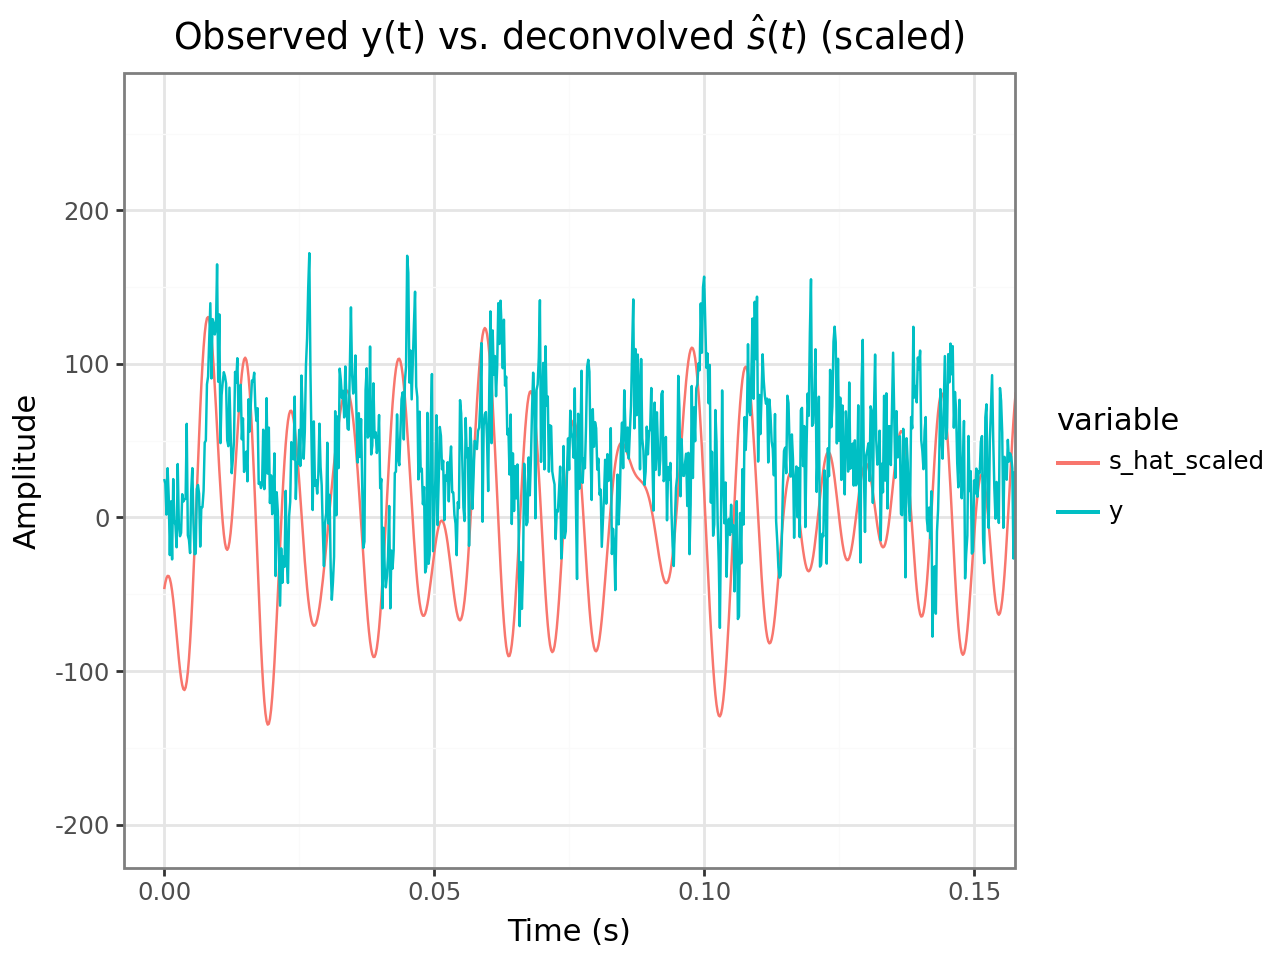

In [28]:
# Cell 7: Binocular variant (optional)
# Synthesize a second channel with gain and noise differences
gain2 = 0.8
y2 = gain2 * y + np.random.normal(0, np.std(y)*0.05, size=len(y))

def tikhonov_deconv_binocular(y_list, h, fs, lam=1e-6, band=(20,150), gains=None):
    """
    Multi-channel per-frequency Tikhonov assuming shared s(t) and kernel h(t) up to gains.
    y_list: list/tuple of 1D arrays (same length) OR a single 1D array (degenerates to single-channel)
    """
    # Coerce input to list of 1D numpy arrays
    if isinstance(y_list, np.ndarray) and y_list.ndim == 1:
        y_list = [y_list]
    elif isinstance(y_list, (list, tuple)):
        y_list = [np.asarray(yy).ravel() for yy in y_list]
    else:
        raise TypeError("y_list must be a 1D numpy array or a list/tuple of 1D arrays")

    C = len(y_list)
    if C == 0:
        raise ValueError("y_list is empty")

    # Enforce common length (trim to min)
    N = min(len(yy) for yy in y_list)
    y_list = [yy[:N] for yy in y_list]

    # Build FFT grid
    h_pad = np.zeros(N)
    h_pad[:min(len(h), N)] = h[:min(len(h), N)]
    H = np.fft.rfft(h_pad)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # Channel FFTs
    Yc = [np.fft.rfft(yy) for yy in y_list]

    # Gains handling
    if gains is None:
        # Crude gain normalisation by RMS
        rms = [np.sqrt(np.mean(yy**2)) + 1e-12 for yy in y_list]
        Yc = [Yc[i] / rms[i] for i in range(C)]
        gc = np.ones(C, dtype=complex)
    else:
        gc = np.asarray(gains, dtype=complex)
        if gc.size != C:
            raise ValueError("gains length must match number of channels")

    # Per-frequency Tikhonov estimator
    num = np.conj(H) * sum(np.conj(gc[i]) * Yc[i] for i in range(C))
    den = (np.abs(H)**2) * np.sum(np.abs(gc)**2) + lam

    # Avoid divide-by-zero (very small |H|); clamp denominator
    den = np.maximum(den, 1e-18)

    S_hat = num / den

    # Optional band-limit
    if band is not None:
        mask = (freqs >= band[0]) & (freqs <= band[1])
        S_hat[~mask] = 0.0

    s_hat = np.fft.irfft(S_hat, n=N)
    return s_hat, freqs, S_hat

# Run deconvolution
# Synthesis grid for MUAP
fs = 4800.0                    # Hz (you can change later)
dt = 1.0 / fs
T_muap = 0.020                # 20 ms support is ample for EOM MUAP
t_muap = np.arange(0.0, T_muap, dt)

h = muap_biphasic(t_muap,
                  Ad=1.0, tau_d=1.0e-3, nd=2,
                  Ar=0.4, tau_r=1.8e-3, nr=2, Delta=0.6e-3,
                  Vrest=0.0)
h = unit_energy(h, dt)
s_hat, f, S_hat = tikhonov_deconv_binocular([y, y2], h, fs=fs, lam=lam, band=(20,150))

# Frequency read-out from |S_hat|^2
band_mask = (f >= 20) & (f <= 150)
P = np.abs(S_hat)**2
k = np.argmax(P[band_mask])
kabs = np.flatnonzero(band_mask)[k]
f_peak = parabolic_subbin(f, P, kabs)

print(f"Estimated dominant firing frequency: {f_peak:.2f} Hz")

# Plot time-domain y and s_hat (scaled for visibility)
scale = np.percentile(np.abs(y), 95) / max(np.percentile(np.abs(s_hat),95), 1e-12)
df_dec = pl.DataFrame({
    "t_s": np.arange(N)/fs,
    "y": y,
    "s_hat_scaled": s_hat*scale
}).to_pandas()

(p9.ggplot(df_dec.melt(id_vars="t_s"), p9.aes("t_s", "value", color="variable")) 
 + p9.geom_line() 
 + p9.theme_bw() 
 + p9.labs(x="Time (s)", y="Amplitude") 
 + p9.ggtitle(r"Observed y(t) vs. deconvolved $\hat{s}(t)$ (scaled)")
 + p9.coord_cartesian(xlim=(0.0, 0.15))
)

